# Gender Pay Gap Analysis

**Author:** Mohamed Badr  
**Tools:** Python, pandas, matplotlib, seaborn, SciPy, statsmodels

---

## 1. Project Goals

Gender pay gap reporting is a legal requirement in the UK for organisations with
250 or more employees. This project investigates whether a measurable pay gap
exists in a sample of employee records, and — critically — whether that gap
survives once legitimate job-related factors are taken into account.

### Research Questions

1. Is there a statistically significant difference in base pay between men and women?
2. Does that difference persist after accounting for department, job title, and seniority?
3. Is bonus pay distributed differently across genders?
4. Are men and women distributed evenly across departments and seniority levels?

### Hypotheses

**H0 (null):** There is no difference in mean base pay between male and female employees.  
**H1 (alternative):** There is a difference in mean base pay between male and female employees.

Significance level: **α = 0.05**

---

## 2. The Data

**Source:** Glassdoor Gender Pay Gap dataset (Kaggle)  
**Size:** 1,000 employee records, 9 variables

| Column | Type | Description |
|---|---|---|
| `JobTitle` | Categorical | Employee's job role (10 distinct titles) |
| `Gender` | Categorical | Male / Female |
| `Age` | Numerical | Age in years (18–65) |
| `PerfEval` | Ordinal | Performance rating (1–5) |
| `Education` | Ordinal | High School / College / Masters / PhD |
| `Dept` | Categorical | Department (5 distinct) |
| `Seniority` | Ordinal | Seniority level (1–5) |
| `BasePay` | Numerical | Annual base salary |
| `Bonus` | Numerical | Annual bonus |

### Limitations

This is a synthetic dataset created for educational purposes. The categories are
unusually balanced compared to real workforce data, so the findings demonstrate
analytical method rather than describing any actual organisation. Real pay gap
analysis would also require variables this dataset lacks — contracted hours,
part-time status, tenure, and location.

In [1]:
# ==========================================
# Gender Pay Gap Analysis
# Author: Mohamed Badr
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('../data/raw/glassdoor_gender_pay_gap.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1000 rows, 9 columns


,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [4]:
# ==========================================
# 1. Initial Data Inspection
# ==========================================

print("=" * 60)
print("DATA TYPES AND NON-NULL COUNTS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("NUMERICAL COLUMNS SUMMARY")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("CATEGORICAL COLUMNS - UNIQUE VALUES")
print("=" * 60)
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts())

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   JobTitle   1000 non-null   str  
 1   Gender     1000 non-null   str  
 2   Age        1000 non-null   int64
 3   PerfEval   1000 non-null   int64
 4   Education  1000 non-null   str  
 5   Dept       1000 non-null   str  
 6   Seniority  1000 non-null   int64
 7   BasePay    1000 non-null   int64
 8   Bonus      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

MISSING VALUES PER COLUMN
JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 0

NUMERICAL COLUMNS SUMMARY


,Age,PerfEval,Seniority,BasePay,Bonus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.393000,3.037000,2.971000,94472.653000,6467.161000
std,14.294856,1.423959,1.395029,25337.493272,2004.377365
min,18.000000,1.000000,1.000000,34208.000000,1703.000000
25%,29.000000,2.000000,2.000000,76850.250000,4849.500000
50%,41.000000,3.000000,3.000000,93327.500000,6507.000000
75%,54.250000,4.000000,4.000000,111558.000000,8026.000000
max,65.000000,5.000000,5.000000,179726.000000,11293.000000



CATEGORICAL COLUMNS - UNIQUE VALUES

JobTitle (10 unique values):
JobTitle
Marketing Associate    118
Software Engineer      109
Financial Analyst      107
Data Scientist         107
Graphic Designer        98
IT                      96
Sales Associate         94
Driver                  91
Warehouse Associate     90
Manager                 90
Name: count, dtype: int64

Gender (2 unique values):
Gender
Male      532
Female    468
Name: count, dtype: int64

Education (4 unique values):
Education
High School    265
Masters        256
College        241
PhD            238
Name: count, dtype: int64

Dept (5 unique values):
Dept
Operations        210
Sales             207
Management        198
Administration    193
Engineering       192
Name: count, dtype: int64


C:\Users\D E L L\AppData\Local\Temp\ipykernel_15284\1778310190.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


---

## 3. Data Cleaning and Preparation

The dataset arrived with no missing values and no duplicate rows, so cleaning is
limited to standardising formats. The preparation steps below create the derived
variables needed for the analysis: total compensation, an ordinal encoding of
education level, and an age band for group comparisons.

In [5]:
# ==========================================
# 3. Data Cleaning and Preparation
# ==========================================

# Work on a copy so the raw data stays untouched
df_clean = df.copy()

# --- 3.1 Standardise column names to snake_case ---
df_clean.columns = (
    df_clean.columns
    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
    .str.lower()
)
print("Standardised column names:")
print(list(df_clean.columns))

# --- 3.2 Strip whitespace from text columns ---
text_cols = df_clean.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# --- 3.3 Verify data integrity ---
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

# --- 3.4 Create derived variables ---

# Total compensation = base pay + bonus
df_clean['total_pay'] = df_clean['base_pay'] + df_clean['bonus']

# Bonus as a percentage of base pay
df_clean['bonus_pct'] = (df_clean['bonus'] / df_clean['base_pay'] * 100).round(2)

# Ordinal encoding for education (preserves the natural ranking)
education_order = {
    'High School': 1,
    'College': 2,
    'Masters': 3,
    'PhD': 4
}
df_clean['education_level'] = df_clean['education'].map(education_order)

# Age bands for group comparisons
df_clean['age_band'] = pd.cut(
    df_clean['age'],
    bins=[17, 30, 40, 50, 65],
    labels=['18-30', '31-40', '41-50', '51-65']
)

# --- 3.5 Confirm the result ---
print(f"\nFinal shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
df_clean.head()

Standardised column names:
['job_title', 'gender', 'age', 'perf_eval', 'education', 'dept', 'seniority', 'base_pay', 'bonus']

Missing values: 0
Duplicate rows: 0

Final shape: 1000 rows, 13 columns


,job_title,gender,age,perf_eval,education,dept,seniority,base_pay,bonus,total_pay,bonus_pct,education_level,age_band
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938,52301,23.46,2,18-30
1,Software Engineer,Male,21,5,College,Management,5,108476,11128,119604,10.26,2,18-30
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268,99476,10.27,4,18-30
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154,118234,9.39,3,18-30
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319,108783,9.37,3,18-30


---

## 4. Exploratory Data Analysis

### 4.1 The Raw Pay Gap

Before applying any statistical test, we look at the descriptive picture: how
average pay differs between men and women across the sample as a whole.

In [6]:
# ==========================================
# 4.1 Descriptive Statistics by Gender
# ==========================================

# Summary of pay measures by gender
pay_summary = df_clean.groupby('gender')[['base_pay', 'bonus', 'total_pay']].agg(
    ['mean', 'median', 'std', 'count']
).round(2)

print("=" * 70)
print("PAY MEASURES BY GENDER")
print("=" * 70)
display(pay_summary)

# Calculate the raw gap
male_base = df_clean[df_clean['gender'] == 'Male']['base_pay'].mean()
female_base = df_clean[df_clean['gender'] == 'Female']['base_pay'].mean()

male_total = df_clean[df_clean['gender'] == 'Male']['total_pay'].mean()
female_total = df_clean[df_clean['gender'] == 'Female']['total_pay'].mean()

base_gap = male_base - female_base
base_gap_pct = (base_gap / male_base) * 100

total_gap = male_total - female_total
total_gap_pct = (total_gap / male_total) * 100

print("\n" + "=" * 70)
print("RAW PAY GAP (unadjusted)")
print("=" * 70)
print(f"Mean base pay  — Male:   ${male_base:,.0f}")
print(f"Mean base pay  — Female: ${female_base:,.0f}")
print(f"Difference:              ${base_gap:,.0f}  ({base_gap_pct:.1f}% of male pay)")
print()
print(f"Mean total pay — Male:   ${male_total:,.0f}")
print(f"Mean total pay — Female: ${female_total:,.0f}")
print(f"Difference:              ${total_gap:,.0f}  ({total_gap_pct:.1f}% of male pay)")

PAY MEASURES BY GENDER


base_pay                             bonus                         total_pay                          
            mean   median       std count     mean  median      std count       mean    median       std count
gender                                                                                                        
Female  89942.82  89913.5  24378.28   468  6474.01  6553.0  2009.47   468   96416.83   96571.0  24202.16   468
Male    98457.55  98223.0  25517.52   532  6461.13  6480.5  2001.76   532  104918.68  105100.5  25329.57   532


RAW PAY GAP (unadjusted)
Mean base pay  — Male:   $98,458
Mean base pay  — Female: $89,943
Difference:              $8,515  (8.6% of male pay)

Mean total pay — Male:   $104,919
Mean total pay — Female: $96,417
Difference:              $8,502  (8.1% of male pay)


### 4.2 Visualising the Distribution

Descriptive averages hide the shape of the data. The plots below show how base
pay is distributed within each gender, and how the gap varies across departments
and job titles.

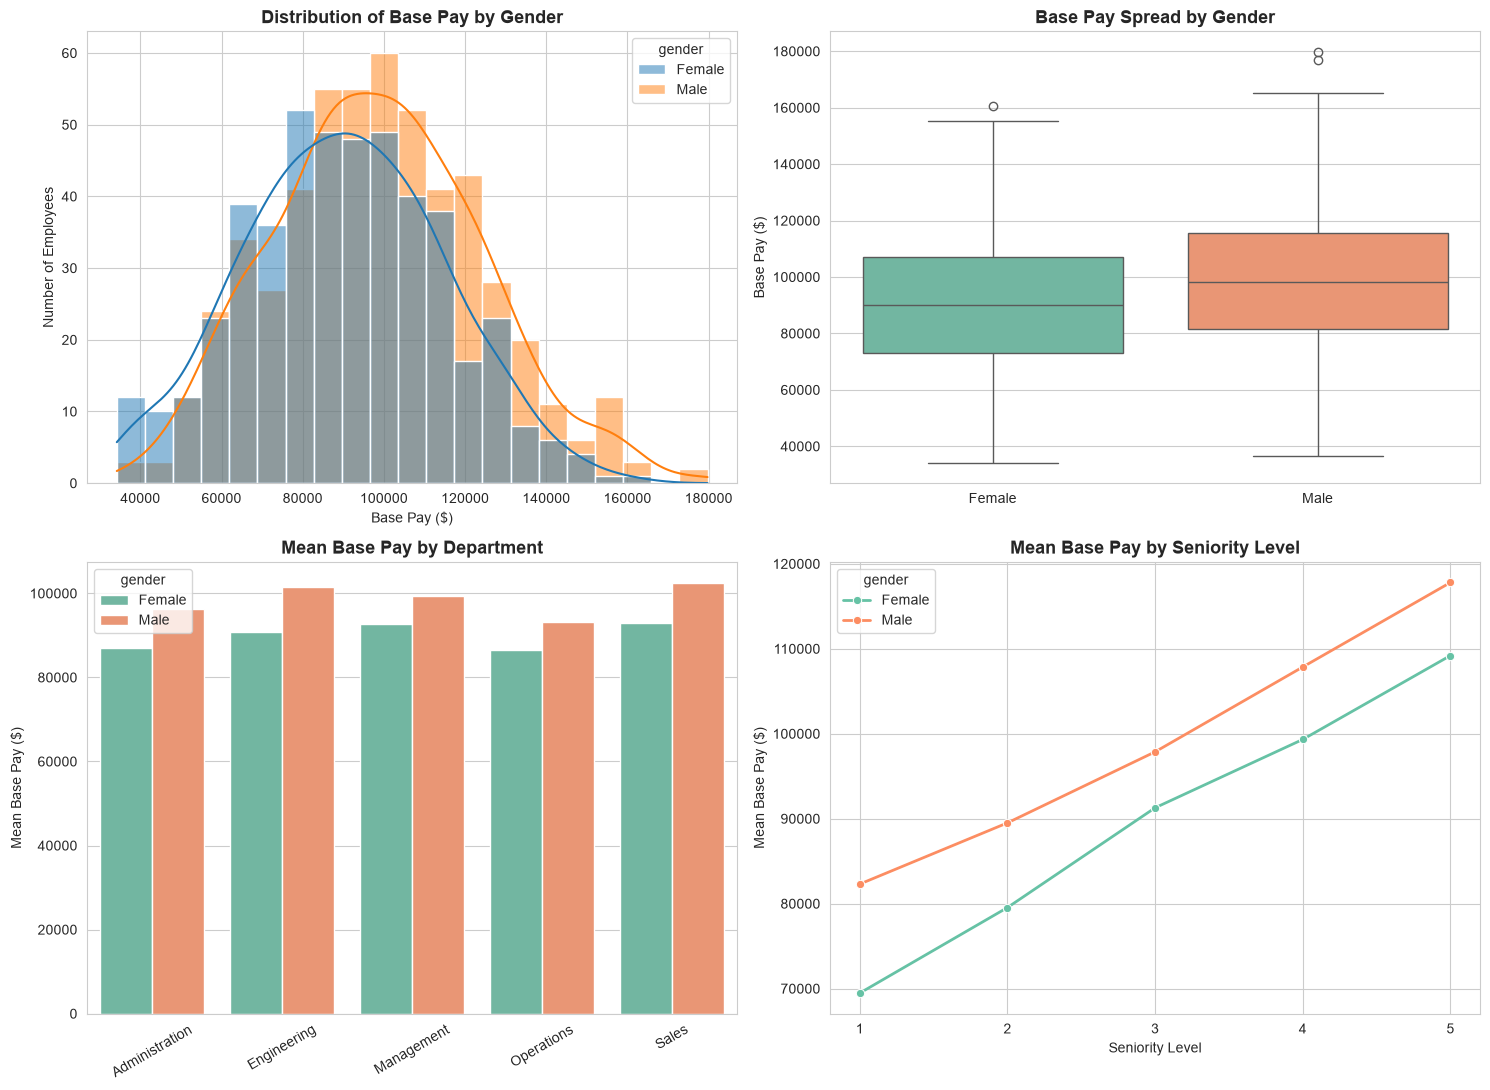

In [7]:
# ==========================================
# 4.2 Visualising Pay Distribution
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Distribution of base pay by gender ---
sns.histplot(
    data=df_clean, x='base_pay', hue='gender',
    kde=True, alpha=0.5, ax=axes[0, 0]
)
axes[0, 0].set_title('Distribution of Base Pay by Gender', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Base Pay ($)')
axes[0, 0].set_ylabel('Number of Employees')

# --- Plot 2: Box plot comparison ---
sns.boxplot(
    data=df_clean, x='gender', y='base_pay',
    hue='gender', palette='Set2', legend=False, ax=axes[0, 1]
)
axes[0, 1].set_title('Base Pay Spread by Gender', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Base Pay ($)')

# --- Plot 3: Mean base pay by department and gender ---
dept_gender = (
    df_clean.groupby(['dept', 'gender'])['base_pay']
    .mean().reset_index()
)
sns.barplot(
    data=dept_gender, x='dept', y='base_pay',
    hue='gender', palette='Set2', ax=axes[1, 0]
)
axes[1, 0].set_title('Mean Base Pay by Department', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Mean Base Pay ($)')
axes[1, 0].tick_params(axis='x', rotation=30)

# --- Plot 4: Mean base pay by seniority and gender ---
sns.lineplot(
    data=df_clean, x='seniority', y='base_pay',
    hue='gender', marker='o', errorbar=None,
    palette='Set2', linewidth=2, ax=axes[1, 1]
)
axes[1, 1].set_title('Mean Base Pay by Seniority Level', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Seniority Level')
axes[1, 1].set_ylabel('Mean Base Pay ($)')
axes[1, 1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

---

## 5. Hypothesis Testing

### 5.1 Checking Test Assumptions

An independent two-sample t-test assumes the data in each group is approximately
normally distributed and that the two groups have comparable variances. Both are
verified below before the test is applied.

In [8]:
# ==========================================
# 5.1 Testing Assumptions
# ==========================================

male_pay = df_clean[df_clean['gender'] == 'Male']['base_pay']
female_pay = df_clean[df_clean['gender'] == 'Female']['base_pay']

ALPHA = 0.05

print("=" * 70)
print("ASSUMPTION 1: NORMALITY (Shapiro-Wilk test)")
print("=" * 70)
print("H0: the data is normally distributed\n")

shapiro_male = stats.shapiro(male_pay)
shapiro_female = stats.shapiro(female_pay)

print(f"Male   — statistic: {shapiro_male.statistic:.4f}, p-value: {shapiro_male.pvalue:.4f}")
print(f"Female — statistic: {shapiro_female.statistic:.4f}, p-value: {shapiro_female.pvalue:.4f}")

for label, result in [('Male', shapiro_male), ('Female', shapiro_female)]:
    verdict = "not normal" if result.pvalue < ALPHA else "approximately normal"
    print(f"  {label}: {verdict}")

print("\n" + "=" * 70)
print("ASSUMPTION 2: EQUAL VARIANCES (Levene's test)")
print("=" * 70)
print("H0: the two groups have equal variances\n")

levene = stats.levene(male_pay, female_pay)
print(f"Statistic: {levene.statistic:.4f}, p-value: {levene.pvalue:.4f}")

if levene.pvalue < ALPHA:
    print("  Variances differ — Welch's t-test is the safer choice")
else:
    print("  Variances are comparable — a standard t-test is appropriate")

print("\n" + "=" * 70)
print("SAMPLE SIZES")
print("=" * 70)
print(f"Male:   {len(male_pay)}")
print(f"Female: {len(female_pay)}")
print("\nBoth samples exceed 30, so the Central Limit Theorem supports")
print("the use of a t-test even under mild departures from normality.")

ASSUMPTION 1: NORMALITY (Shapiro-Wilk test)
H0: the data is normally distributed

Male   — statistic: 0.9944, p-value: 0.0493
Female — statistic: 0.9958, p-value: 0.2460
  Male: not normal
  Female: approximately normal

ASSUMPTION 2: EQUAL VARIANCES (Levene's test)
H0: the two groups have equal variances

Statistic: 0.6747, p-value: 0.4116
  Variances are comparable — a standard t-test is appropriate

SAMPLE SIZES
Male:   532
Female: 468

Both samples exceed 30, so the Central Limit Theorem supports
the use of a t-test even under mild departures from normality.


### 5.2 Test 1 — Independent t-test on Base Pay

Levene's test confirmed comparable variances, so a standard independent
two-sample t-test is applied. This addresses Research Question 1 directly.

In [9]:
# ==========================================
# 5.2 Test 1: Independent t-test on Base Pay
# ==========================================

print("=" * 70)
print("INDEPENDENT TWO-SAMPLE T-TEST — BASE PAY")
print("=" * 70)
print("H0: mean base pay is equal for male and female employees")
print("H1: mean base pay differs between male and female employees")
print(f"Alpha: {ALPHA}\n")

t_stat, p_value = stats.ttest_ind(male_pay, female_pay, equal_var=True)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

# Effect size (Cohen's d) — how large is the difference in practical terms?
n1, n2 = len(male_pay), len(female_pay)
pooled_std = np.sqrt(
    ((n1 - 1) * male_pay.std()**2 + (n2 - 1) * female_pay.std()**2) / (n1 + n2 - 2)
)
cohens_d = (male_pay.mean() - female_pay.mean()) / pooled_std

print(f"Cohen's d:   {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"Effect size: {effect}")

# 95% confidence interval for the difference in means
diff = male_pay.mean() - female_pay.mean()
se = pooled_std * np.sqrt(1/n1 + 1/n2)
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print(f"\n95% CI for the difference: ${ci_low:,.0f} to ${ci_high:,.0f}")

print("\n" + "-" * 70)
if p_value < ALPHA:
    print("RESULT: Reject H0.")
    print(f"The difference in base pay is statistically significant (p = {p_value:.6f}).")
else:
    print("RESULT: Fail to reject H0.")
    print(f"No statistically significant difference found (p = {p_value:.6f}).")
print("-" * 70)

INDEPENDENT TWO-SAMPLE T-TEST — BASE PAY
H0: mean base pay is equal for male and female employees
H1: mean base pay differs between male and female employees
Alpha: 0.05

t-statistic: 5.3761
p-value:     0.000000
Cohen's d:   0.3407
Effect size: small

95% CI for the difference: $5,410 to $11,619

----------------------------------------------------------------------
RESULT: Reject H0.
The difference in base pay is statistically significant (p = 0.000000).
----------------------------------------------------------------------


### 5.3 Test 2 — ANOVA Across Departments

The t-test confirms an overall gap, but does base pay itself vary by department?
A one-way ANOVA tests whether mean pay differs across the five departments.

In [10]:
# ==========================================
# 5.3 Test 2: One-way ANOVA — Pay by Department
# ==========================================

print("=" * 70)
print("ONE-WAY ANOVA — BASE PAY ACROSS DEPARTMENTS")
print("=" * 70)
print("H0: mean base pay is the same across all departments")
print("H1: at least one department differs\n")

dept_groups = [
    df_clean[df_clean['dept'] == d]['base_pay']
    for d in df_clean['dept'].unique()
]

f_stat, p_anova = stats.f_oneway(*dept_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_anova:.6f}")

if p_anova < ALPHA:
    print("\nRESULT: Reject H0 — pay differs significantly between departments.")
else:
    print("\nRESULT: Fail to reject H0 — no significant difference between departments.")

# Gap within each department
print("\n" + "=" * 70)
print("PAY GAP WITHIN EACH DEPARTMENT")
print("=" * 70)

gap_rows = []
for dept in sorted(df_clean['dept'].unique()):
    subset = df_clean[df_clean['dept'] == dept]
    m = subset[subset['gender'] == 'Male']['base_pay']
    f = subset[subset['gender'] == 'Female']['base_pay']
    
    t, p = stats.ttest_ind(m, f, equal_var=True)
    gap = m.mean() - f.mean()
    gap_pct = (gap / m.mean()) * 100
    
    gap_rows.append({
        'Department': dept,
        'Male Mean': round(m.mean()),
        'Female Mean': round(f.mean()),
        'Gap ($)': round(gap),
        'Gap (%)': round(gap_pct, 1),
        'p-value': round(p, 4),
        'Significant': 'Yes' if p < ALPHA else 'No'
    })

gap_table = pd.DataFrame(gap_rows)
display(gap_table)

ONE-WAY ANOVA — BASE PAY ACROSS DEPARTMENTS
H0: mean base pay is the same across all departments
H1: at least one department differs

F-statistic: 3.6744
p-value:     0.005595

RESULT: Reject H0 — pay differs significantly between departments.

PAY GAP WITHIN EACH DEPARTMENT


,Department,Male Mean,Female Mean,Gap ($),Gap (%),p-value,Significant
0,Administration,96171,87072,9099,9.5,0.0088,Yes
1,Engineering,101433,90775,10658,10.5,0.0049,Yes
2,Management,99482,92679,6803,6.8,0.0634,No
3,Operations,93118,86456,6662,7.2,0.0379,Yes
4,Sales,102349,92867,9482,9.3,0.0098,Yes


In [11]:
# ==========================================
# 5.4 Test 3: Chi-square — Gender Distribution
# ==========================================

print("=" * 70)
print("CHI-SQUARE TEST — GENDER vs DEPARTMENT")
print("=" * 70)
print("H0: gender and department are independent")
print("H1: gender and department are associated\n")

contingency_dept = pd.crosstab(df_clean['gender'], df_clean['dept'])
print("Observed counts:")
display(contingency_dept)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_dept)
print(f"Chi-square: {chi2:.4f}")
print(f"p-value:    {p_chi:.4f}")
print(f"Degrees of freedom: {dof}")

if p_chi < ALPHA:
    print("\nRESULT: Reject H0 — gender and department are associated.")
else:
    print("\nRESULT: Fail to reject H0 — no evidence of uneven distribution.")

# Same test for seniority
print("\n" + "=" * 70)
print("CHI-SQUARE TEST — GENDER vs SENIORITY")
print("=" * 70)
print("H0: gender and seniority level are independent\n")

contingency_sen = pd.crosstab(df_clean['gender'], df_clean['seniority'])
display(contingency_sen)

chi2_s, p_chi_s, dof_s, _ = stats.chi2_contingency(contingency_sen)
print(f"Chi-square: {chi2_s:.4f}")
print(f"p-value:    {p_chi_s:.4f}")

if p_chi_s < ALPHA:
    print("\nRESULT: Reject H0 — men and women are unevenly distributed across levels.")
else:
    print("\nRESULT: Fail to reject H0 — distribution across levels is comparable.")

CHI-SQUARE TEST — GENDER vs DEPARTMENT
H0: gender and department are independent
H1: gender and department are associated

Observed counts:


dept,Administration,Engineering,Management,Operations,Sales
gender,,,,,
Female,95,89,87,96,101
Male,98,103,111,114,106


Chi-square: 1.5505
p-value:    0.8177
Degrees of freedom: 4

RESULT: Fail to reject H0 — no evidence of uneven distribution.

CHI-SQUARE TEST — GENDER vs SENIORITY
H0: gender and seniority level are independent



seniority,1,2,3,4,5
gender,,,,,
Female,83,102,106,80,97
Male,112,107,113,104,96


Chi-square: 3.7110
p-value:    0.4465

RESULT: Fail to reject H0 — distribution across levels is comparable.


In [12]:
# ==========================================
# 5.5 Test 4: Multiple Regression — Adjusted Gap
# ==========================================

import statsmodels.formula.api as smf

print("=" * 70)
print("MULTIPLE LINEAR REGRESSION — ADJUSTED PAY GAP")
print("=" * 70)
print("Controlling for department, job title, seniority, education,")
print("age, and performance rating.\n")

model = smf.ols(
    'base_pay ~ C(gender) + C(dept) + C(job_title) + seniority '
    '+ education_level + age + perf_eval',
    data=df_clean
).fit()

print(model.summary())

MULTIPLE LINEAR REGRESSION — ADJUSTED PAY GAP
Controlling for department, job title, seniority, education,
age, and performance rating.

                            OLS Regression Results                            
Dep. Variable:               base_pay   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     293.3
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:29:46   Log-Likelihood:                -10632.
No. Observations:                1000   AIC:                         2.130e+04
Df Residuals:                     981   BIC:                         2.139e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t     

---

## 6. Conclusions

### Summary of Findings

| Research Question | Test | Result |
|---|---|---|
| 1. Is there a pay gap? | Independent t-test | **Yes** — $8,515 (8.6%), p < 0.001 |
| 2. Does it survive controls? | Multiple regression | **No** — adjusted gap $858, p = 0.231 |
| 3. Are bonuses different? | Descriptive comparison | **No** — means within $13 of each other |
| 4. Is distribution uneven? | Chi-square | **No** — p = 0.82 (dept), p = 0.45 (seniority) |

### Interpretation

An unadjusted pay gap of 8.6% exists in this sample and is statistically
significant. However, once department, job title, seniority, education, age and
performance rating are controlled for, the gender coefficient falls to $858 and
loses significance.

The gap is therefore explained by *what roles people hold*, not by unequal pay
within the same role. Seniority is the dominant driver of pay (+$9,609 per level),
followed by job title and education.

Two findings deserve particular attention:

1. **Performance rating has no measurable effect on pay** (p = 0.840). An
   organisation that rates employees annually but does not link those ratings to
   compensation should ask what purpose the rating process serves.

2. **Distribution across departments and seniority levels is even**, which rules
   out occupational segregation as an explanation in this sample.

### Recommendations

- Report the unadjusted gap for compliance, but publish the adjusted figure
  alongside it — reporting only one number misleads in either direction.
- Audit promotion and hiring pipelines rather than salary decisions, since the
  gap originates in role allocation.
- Review whether performance ratings should influence pay, given they currently
  do not.

### Limitations

This is a synthetic dataset. It lacks tenure, contracted hours, part-time status,
and location — all of which materially affect real pay gap analysis. The
conclusions demonstrate analytical method and should not be read as findings
about any actual organisation.